In [4]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
rng = np.random.default_rng(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


=== Image Counts per Split ===
Train - premium: 2400, longberry: 2400, defect: 2400, defect: 2400
Val   - premium: 800, longberry: 800, peaberry: 800, defect: 800
Test  - premium: 800, longberry: 800, peaberry: 800, defect: 800

Train Class Imbalance Ratio (premium / premium): 1.00x

=== Visual Sample Analysis ===
Sample [premium #1]: Size = 256x256px, Color Mode = RGB
Sample [premium #2]: Size = 256x256px, Color Mode = RGB
Sample [premium #3]: Size = 256x256px, Color Mode = RGB
Sample [premium #4]: Size = 256x256px, Color Mode = RGB
Sample [premium #5]: Size = 256x256px, Color Mode = RGB
Sample [longberry #1]: Size = 256x256px, Color Mode = RGB
Sample [longberry #2]: Size = 256x256px, Color Mode = RGB
Sample [longberry #3]: Size = 256x256px, Color Mode = RGB
Sample [longberry #4]: Size = 256x256px, Color Mode = RGB
Sample [longberry #5]: Size = 256x256px, Color Mode = RGB
Sample [peaberry #1]: Size = 256x256px, Color Mode = RGB
Sample [peaberry #2]: Size = 256x256px, Color Mode = RGB


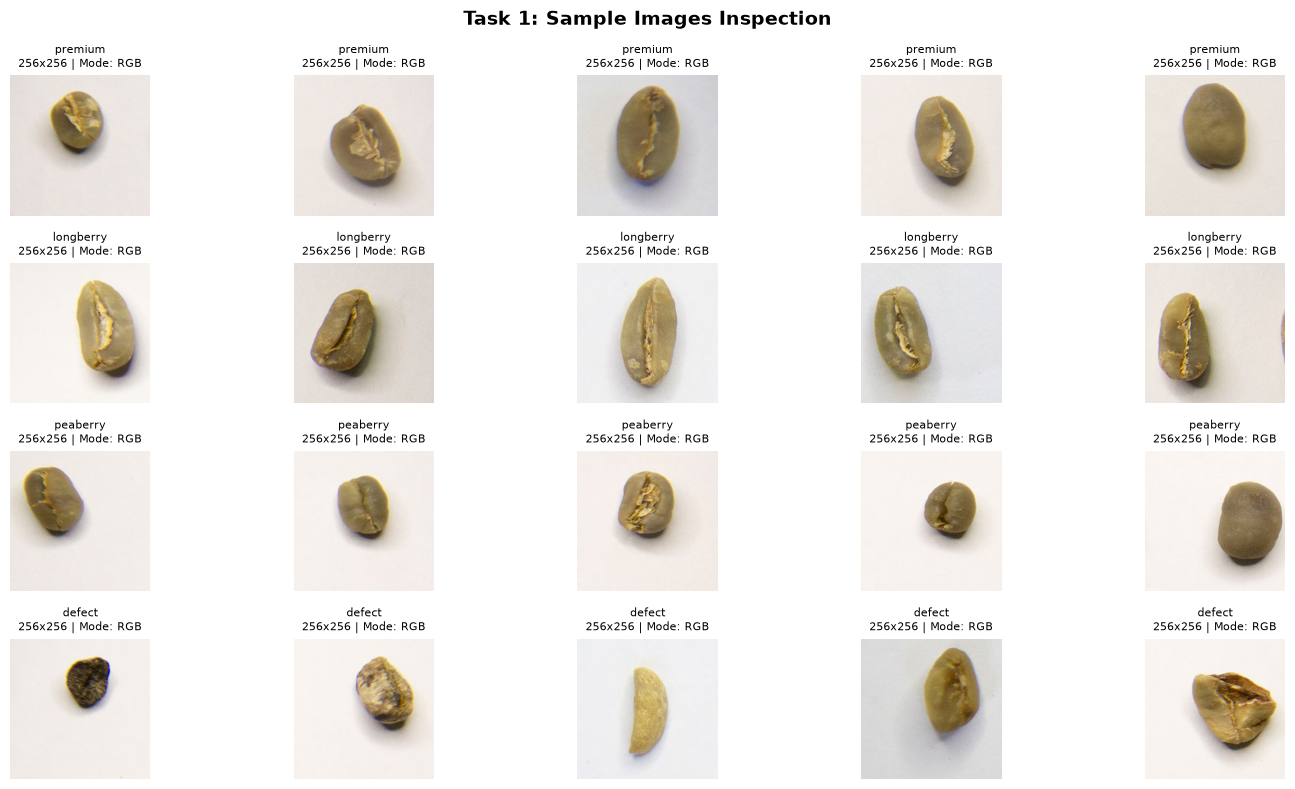

In [5]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\ruthg\Downloads\coffee_dataset"

def display_samples_and_check(base_dir, num_samples=5):
    """
    Samples and displays images per class with dimension and color mode metadata.
    """
    train_dir = os.path.join(base_dir, "train")
    classes = ["premium", "longberry", "peaberry", "defect"]
    
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 8))
    
    print("=== Visual Sample Analysis ===")
    for i, cls in enumerate(classes):
        cls_path = os.path.join(train_dir, cls)
        
        # Support multiple image extensions
        img_paths = (
            glob.glob(os.path.join(cls_path, "*.jpeg")) + 
            glob.glob(os.path.join(cls_path, "*.jpg")) +
            glob.glob(os.path.join(cls_path, "*.png")) +
            glob.glob(os.path.join(cls_path, "*.JPEG")) +
            glob.glob(os.path.join(cls_path, "*.JPG"))
        )[:num_samples]
        
        if not img_paths:
            print(f"Warning: No images found for class '{cls}' in {cls_path}")
            continue

        for j, img_path in enumerate(img_paths):
            with Image.open(img_path) as img:
                width, height = img.size
                mode = img.mode
                
                ax = axes[i, j] if len(classes) > 1 else axes[j]
                ax.imshow(img, cmap='gray' if mode == 'L' else None)
                ax.set_title(f"{cls}\n{width}x{height} | Mode: {mode}", fontsize=8)
                ax.axis('off')
                
                print(f"Sample [{cls} #{j+1}]: Size = {width}x{height}px, Color Mode = {mode}")

    plt.suptitle("Task 1: Sample Images Inspection", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def inspect_dataset(base_dir):
    """
    Counts images across dataset splits, evaluates class imbalance, 
    and triggers visual sample inspection.
    """
    train_dir = os.path.join(base_dir, "train")
    test_dir = os.path.join(base_dir, "test")
    val_dir = os.path.join(base_dir, "val")
    
    classes = ["premium", "longberry", "peaberry", "defect"]
    counts = {}
    
    for split_name, split_path in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
        counts[split_name] = {}
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            imgs = (
                glob.glob(os.path.join(cls_path, "*.jpeg")) +
                glob.glob(os.path.join(cls_path, "*.jpg")) +
                glob.glob(os.path.join(cls_path, "*.png")) +
                glob.glob(os.path.join(cls_path, "*.JPEG")) +
                glob.glob(os.path.join(cls_path, "*.JPG"))
            )
            counts[split_name][cls] = len(imgs)

    print("=== Image Counts per Split ===")
    print(f"Train - premium: {counts['train']['premium']}, longberry: {counts['train']['longberry']}, defect: {counts['train']['peaberry']}, defect: {counts['train']['defect']}")
    print(f"Val   - premium: {counts['val']['premium']}, longberry: {counts['val']['longberry']}, peaberry: {counts['val']['peaberry']}, defect: {counts['val']['defect']}")
    print(f"Test  - premium: {counts['test']['premium']}, longberry: {counts['test']['longberry']}, peaberry: {counts['test']['peaberry']}, defect: {counts['test']['defect']}\n")
    
    # Calculate imbalance ratio relative to largest vs smallest class in training set
    train_counts = counts['train']
    max_cls = max(train_counts, key=train_counts.get)
    min_cls = min(train_counts, key=train_counts.get)
    
    if train_counts[min_cls] > 0:
        imbalance_ratio = train_counts[max_cls] / train_counts[min_cls]
        print(f"Train Class Imbalance Ratio ({max_cls} / {min_cls}): {imbalance_ratio:.2f}x\n")
    else:
        print(f"Warning: Class '{min_cls}' has 0 training images.\n")

    # Display image grid and details
    display_samples_and_check(base_dir, num_samples=5)


if __name__ == "__main__":
    inspect_dataset(DATA_DIR)

In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

DATA_DIR = r"C:\Users\ruthg\Downloads\coffee_dataset"
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

def compute_class_weights(train_ds):
    """
    Computes class weights based on the unaugmented training set count.
    0: defect, 1: longberry, 2: peaberry, 3: premium
    """
    # Extract only the target labels without loading image arrays into memory
    labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
    
    total = len(labels)
    n_defect = np.sum(labels == 0)
    n_longberry = np.sum(labels == 1)
    n_peaberry = np.sum(labels == 2)
    n_premium = np.sum(labels == 3)
    
    weight_for_0 = (1 / n_defect) * (total / 4.0)
    weight_for_1 = (1 / n_longberry) * (total / 4.0)
    weight_for_2 = (1 / n_peaberry) * (total / 4.0)
    weight_for_3 = (1 / n_premium) * (total / 4.0)
    
    class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2, 3: weight_for_3}
    
    print(f"Total Train Samples: {total}")
    print(f"Defect (Class 0): {n_defect} | Computed Weight: {weight_for_0:.2f}")
    print(f"Longberry (Class 1): {n_longberry} | Computed Weight: {weight_for_1:.2f}")
    print(f"Peaberry (Class 2): {n_peaberry} | Computed Weight: {weight_for_2:.2f}")
    print(f"Premium (Class 3): {n_premium} | Computed Weight: {weight_for_3:.2f}")
    
    return class_weight

def get_data_pipelines(data_dir):
    train_path = os.path.join(data_dir, "train")
    val_path = os.path.join(data_dir, "val")
    test_path = os.path.join(data_dir, "test")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_path,
        image_size=IMG_SIZE,
        color_mode="grayscale",
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=True,
        seed=42
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_path,
        image_size=IMG_SIZE,
        color_mode="grayscale",
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_path,
        image_size=IMG_SIZE,
        color_mode="grayscale",
        batch_size=BATCH_SIZE,
        label_mode="int",
        shuffle=False
    )

    class_weights = compute_class_weights(train_ds)

    rescaling = layers.Rescaling(1.0 / 255.0)

    # Note the value_range parameter added to RandomBrightness
    data_augmentation = tf.keras.Sequential([
        layers.RandomRotation(factor=0.04),
        layers.RandomZoom(height_factor=(-0.1, 0.1)),
        layers.RandomFlip("horizontal"),
        layers.RandomBrightness(factor=0.1, value_range=(0.0, 1.0))
    ], name="data_augmentation")

    # Train: Cache raw un-augmented images -> map transformations -> prefetch
    train_ds = (
        train_ds
        .cache()
        .map(
            lambda x, y: (tf.clip_by_value(data_augmentation(rescaling(x), training=True), 0.0, 1.0), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )
    
    # Val & Test: Cache rescaled images directly
    val_ds = (
        val_ds
        .map(lambda x, y: (rescaling(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )
    
    test_ds = (
        test_ds
        .map(lambda x, y: (rescaling(x), y), num_parallel_calls=tf.data.AUTOTUNE)
        .cache()
        .prefetch(buffer_size=tf.data.AUTOTUNE)
    )

    return train_ds, val_ds, test_ds, class_weights

if __name__ == "__main__":
    train_ds, val_ds, test_ds, class_weights = get_data_pipelines(DATA_DIR)
    
    for images, labels in train_ds.take(1):
        print("\n=== Verification ===")
        print(f"Batch Image Shape: {images.shape}")
        print(f"Batch Labels Shape: {labels.shape}")
        print(f"Pixel Min: {tf.reduce_min(images):.2f}, Pixel Max: {tf.reduce_max(images):.2f}")

Found 4800 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Total Train Samples: 4800
Defect (Class 0): 1200 | Computed Weight: 1.00
Longberry (Class 1): 1200 | Computed Weight: 1.00
Peaberry (Class 2): 1200 | Computed Weight: 1.00
Premium (Class 3): 1200 | Computed Weight: 1.00

=== Verification ===
Batch Image Shape: (32, 150, 150, 1)
Batch Labels Shape: (32,)
Pixel Min: 0.03, Pixel Max: 1.00


In [13]:
from tensorflow.keras import models, layers

def build_model(input_shape=(150, 150, 1), num_classes=4):
    model = models.Sequential([
        # Input & Block 1
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Classification Head
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        
        # FIXED: 4 output nodes for 4 coffee classes using Softmax
        layers.Dense(num_classes, activation="softmax")
    ])

    # FIXED: Sparse Categorical Crossentropy for integer labels (0, 1, 2, 3)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

if __name__ == "__main__":
    model = build_model((150, 150, 1), num_classes=4)
    model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,188 (18.42 MB)

 Trainable params: 4,828,740 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,  
    callbacks=[early_stop]
)

Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 97s 595ms/step - accuracy: 0.2910 - loss: 1.9766 - val_accuracy: 0.2500 - val_loss: 9.5795
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 94s 620ms/step - accuracy: 0.3381 - loss: 1.3985 - val_accuracy: 0.2412 - val_loss: 5.4432
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 93s 614ms/step - accuracy: 0.4242 - loss: 1.2938 - val_accuracy: 0.2969 - val_loss: 2.7675
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 92s 614ms/step - accuracy: 0.4698 - loss: 1.2072 - val_accuracy: 0.2569 - val_loss: 4.2274
Epoch 5/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 119s 792ms/step - accuracy: 0.5346 - loss: 1.0934 - val_accuracy: 0.2931 - val_loss: 2.2267
Epoch 6/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.5650 - loss: 1.0273 - val_accuracy: 0.3025 - val_loss: 1.9563
Epoch 7/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 149s 960ms/step - accuracy: 0.5831 - loss: 1.0173 - val_accuracy: 0.2500 - val_loss: 36.1593
Epoch 8/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 128s 843ms/step - accuracy: 0.6425 - loss:

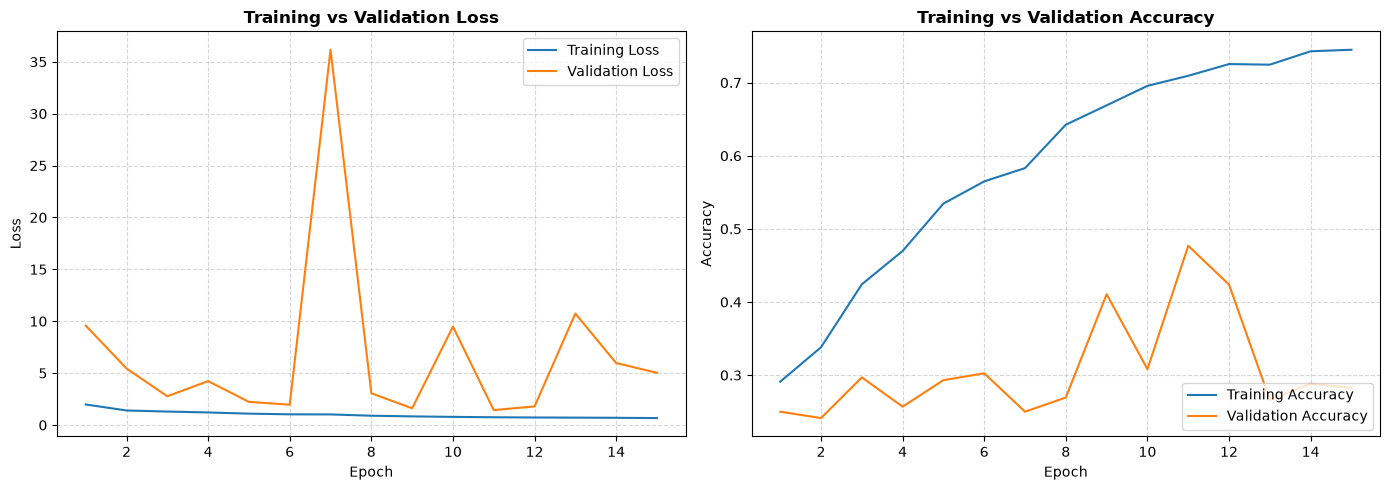

In [15]:

# Extract metric values from training history
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Subplot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

# Subplot 2: Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.5106 - loss: 1.3024

Final Test Loss:     1.3024
Final Test Accuracy: 51.06%

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step
=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

   Defect (0)     0.4113    0.7475    0.5306       400
Longberry (1)     0.7292    0.5925    0.6538       400
 Peaberry (2)     0.5057    0.5575    0.5303       400
  Premium (3)     0.5421    0.1450    0.2288       400

     accuracy                         0.5106      1600
    macro avg     0.5471    0.5106    0.4859      1600
 weighted avg     0.5471    0.5106    0.4859      1600



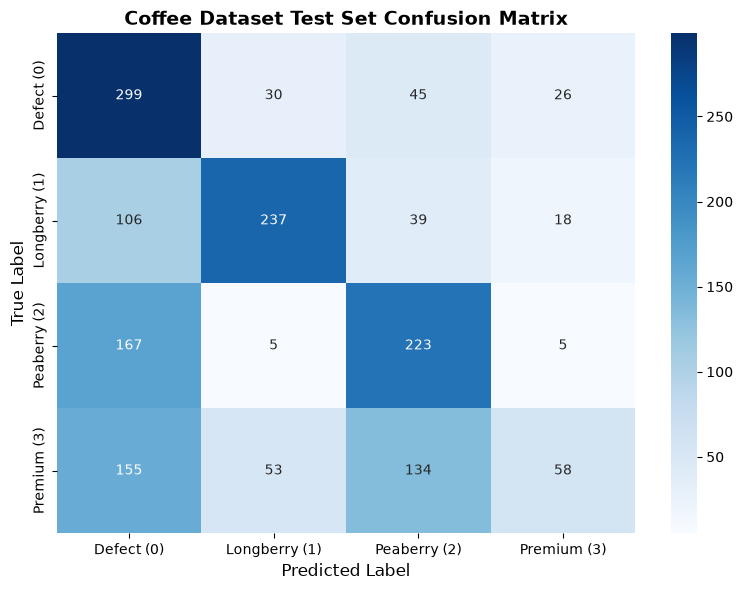

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluate overall loss and accuracy on the untouched test set
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nFinal Test Loss:     {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

# 2. Extract true labels across all batches
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# 3. Predict raw probability distributions for each sample (shape: [N, 4])
y_pred_probs = model.predict(test_ds, verbose=1)

# 4. Convert probabilities to discrete class indices (0, 1, 2, or 3)
y_pred = np.argmax(y_pred_probs, axis=1)

# 5. Define class names matching dataset folder indices
class_names = ["Defect (0)", "Longberry (1)", "Peaberry (2)", "Premium (3)"]

# 6. Print detailed Classification Report (Precision, Recall, F1 per class)
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 7. Compute and Plot 4x4 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Coffee Dataset Test Set Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()